# 03 — Model Training with MLflow
**Trains:** XGBoost + Isolation Forest → composite score
**Tracks:** All runs in MLflow experiment `fraud_detection_phase1`

## 1. Setup

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
import warnings

from src.features import normalize_iforest_scores, composite_score

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
print('imports ok')

imports ok


## 2. Load Processed Data

In [3]:
X_tr      = pd.read_parquet('../data/processed/X_tr_raw.parquet')
X_val     = pd.read_parquet('../data/processed/X_val_raw.parquet')
X_tr_smt  = pd.read_parquet('../data/processed/X_tr_smt.parquet')
X_val_imp = pd.read_parquet('../data/processed/X_val_imp.parquet')
y_tr      = pd.read_parquet('../data/processed/y_tr.parquet')['isFraud']
y_val     = pd.read_parquet('../data/processed/y_val.parquet')['isFraud']
y_tr_smt  = pd.read_parquet('../data/processed/y_tr_smt.parquet')['isFraud']

feature_cols = joblib.load('../models/feature_cols.pkl')

neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
scale_pos_weight = neg / pos

print(f'X_tr: {X_tr.shape}  X_tr_smt: {X_tr_smt.shape}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

X_tr: (472432, 470)  X_tr_smt: (904270, 470)
scale_pos_weight: 27.5


## 3. MLflow Setup

In [4]:
# Use local file-based MLflow tracking (no server needed)
mlflow.set_tracking_uri('../mlruns')
experiment = mlflow.set_experiment('fraud_detection_phase1')
print(f'Experiment ID: {experiment.experiment_id}')

2026/03/26 23:19:48 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection_phase1' does not exist. Creating a new experiment.


Experiment ID: 748752566202607536


## 4. Helper Functions

In [5]:
def recall_at_fpr(y_true, y_score, target_fpr=0.05):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    idx = np.searchsorted(fpr, target_fpr)
    return float(tpr[min(idx, len(tpr)-1)])

def evaluate_scores(y_true, y_score, label=''):
    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr  = average_precision_score(y_true, y_score)
    rec5    = recall_at_fpr(y_true, y_score, 0.05)
    print(f'{label:30s}  AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}  Recall@5%FPR: {rec5:.4f}')
    return {'auc_roc': auc_roc, 'auc_pr': auc_pr, 'recall_at_5pct_fpr': rec5}

def plot_curves(y_true, y_score, label, ax_roc, ax_pr, color):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr  = average_precision_score(y_true, y_score)
    ax_roc.plot(fpr, tpr, color=color, label=f'{label} (AUC={auc_roc:.4f})')
    ax_pr.plot(rec, prec, color=color, label=f'{label} (AP={auc_pr:.4f})')

## 5. Train Baseline XGBoost

In [6]:
XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=9,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    device='cpu',
    early_stopping_rounds=50,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
)

with mlflow.start_run(run_name='xgb_baseline') as run_base:
    mlflow.log_params({**XGB_PARAMS, 'smote': False, 'dataset': 'ieee_cis'})

    xgb_base = XGBClassifier(**XGB_PARAMS)
    xgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

    y_pred_base = xgb_base.predict_proba(X_val)[:, 1]
    metrics_base = evaluate_scores(y_val, y_pred_base, 'XGB Baseline')

    mlflow.log_metrics(metrics_base)
    mlflow.xgboost.log_model(xgb_base, 'xgb_baseline_model')

    run_id_base = run_base.info.run_id
    print(f'Run ID: {run_id_base}')

[0]	validation_0-auc:0.82210
[100]	validation_0-auc:0.89871
[200]	validation_0-auc:0.90303
[203]	validation_0-auc:0.90280


2026/03/26 23:23:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGB Baseline                    AUC-ROC: 0.9037  AUC-PR: 0.4995  Recall@5%FPR: 0.6255
Run ID: 8e6797bb1f3f47c99160e0de21bc8b76


## 6. Train XGBoost + SMOTETomek

In [7]:
XGB_SMT_PARAMS = dict(
    n_estimators=500,
    max_depth=9,
    learning_rate=0.05,
    tree_method='hist',
    device='cpu',
    early_stopping_rounds=50,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
)

with mlflow.start_run(run_name='xgb_smotetomek') as run_smt:
    mlflow.log_params({**XGB_SMT_PARAMS, 'smote': True, 'dataset': 'ieee_cis'})

    xgb_smt = XGBClassifier(**XGB_SMT_PARAMS)
    xgb_smt.fit(X_tr_smt, y_tr_smt, eval_set=[(X_val_imp, y_val)], verbose=100)

    y_pred_smt = xgb_smt.predict_proba(X_val_imp)[:, 1]
    metrics_smt = evaluate_scores(y_val, y_pred_smt, 'XGB + SMOTETomek')

    mlflow.log_metrics(metrics_smt)
    mlflow.xgboost.log_model(xgb_smt, 'xgb_smt_model')

    run_id_smt = run_smt.info.run_id
    print(f'Run ID: {run_id_smt}')

[0]	validation_0-auc:0.80484
[100]	validation_0-auc:0.87791
[200]	validation_0-auc:0.89706
[300]	validation_0-auc:0.90344
[400]	validation_0-auc:0.90829
[499]	validation_0-auc:0.91084


2026/03/26 23:32:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGB + SMOTETomek                AUC-ROC: 0.9109  AUC-PR: 0.5594  Recall@5%FPR: 0.6774
Run ID: a9fb42d6c4f64e67a2f1f99641c5ce19


## 7. Train Isolation Forest

2026/03/26 23:32:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 23:32:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Isolation Forest                AUC-ROC: 0.7706  AUC-PR: 0.1188  Recall@5%FPR: 0.3164


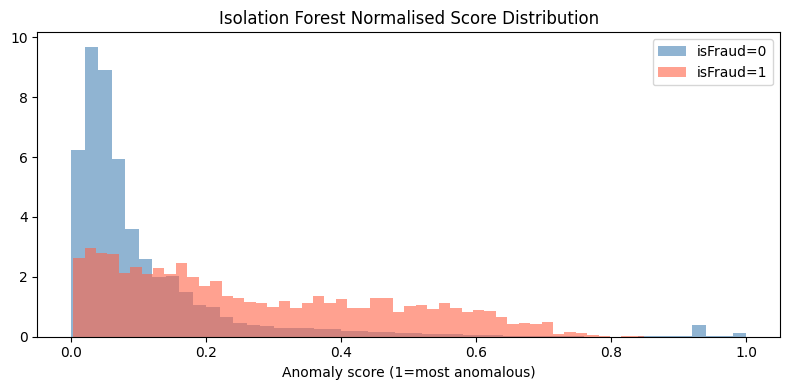

Run ID: c195996e6fef4249bb43e0bd1a0168a5


In [8]:
IFOREST_PARAMS = dict(
    n_estimators=200,
    contamination=0.035,  # approximate fraud rate
    max_samples='auto',
    random_state=SEED,
    n_jobs=-1,
)

with mlflow.start_run(run_name='isolation_forest') as run_if:
    mlflow.log_params({**IFOREST_PARAMS, 'dataset': 'ieee_cis'})

    # IsolationForest is unsupervised — train on legitimate transactions only
    from sklearn.impute import SimpleImputer
    imputer = joblib.load('../models/imputer.pkl')
    X_tr_imp = pd.DataFrame(imputer.transform(X_tr), columns=X_tr.columns)

    iforest = IsolationForest(**IFOREST_PARAMS)
    iforest.fit(X_tr_imp[y_tr == 0])  # fit on legit only

    # decision_function: negative = anomalous, positive = normal
    raw_scores_val = iforest.decision_function(X_val_imp)
    iforest_scores_val = normalize_iforest_scores(raw_scores_val)

    metrics_if = evaluate_scores(y_val, iforest_scores_val, 'Isolation Forest')
    mlflow.log_metrics(metrics_if)
    mlflow.sklearn.log_model(iforest, 'iforest_model')

    # Plot anomaly score distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = y_val.values == label
        ax.hist(iforest_scores_val[mask], bins=50, alpha=0.6,
                label=f'isFraud={label}', color=color, density=True)
    ax.set_title('Isolation Forest Normalised Score Distribution')
    ax.set_xlabel('Anomaly score (1=most anomalous)')
    ax.legend()
    plt.tight_layout()
    fig.savefig('/tmp/iforest_dist.png', dpi=120, bbox_inches='tight')
    mlflow.log_artifact('/tmp/iforest_dist.png')
    plt.savefig('../results/03_iforest_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    run_id_if = run_if.info.run_id
    print(f'Run ID: {run_id_if}')

## 8. Composite Score Sensitivity Analysis

Test weights (alpha × XGB + (1-alpha) × IForest) at 5 settings.

In [9]:
alphas = [0.5, 0.6, 0.7, 0.8, 0.9]
sensitivity_results = []

for alpha in alphas:
    with mlflow.start_run(run_name=f'composite_alpha_{alpha}'):
        mlflow.log_param('alpha', alpha)
        mlflow.log_param('dataset', 'ieee_cis')

        comp = np.array([
            composite_score(float(xp), float(ip), alpha=alpha)
            for xp, ip in zip(y_pred_smt, iforest_scores_val)
        ])
        m = evaluate_scores(y_val, comp, f'Composite alpha={alpha}')
        mlflow.log_metrics(m)
        sensitivity_results.append({'alpha': alpha, **m})

sens_df = pd.DataFrame(sensitivity_results).set_index('alpha')
print('\nSensitivity analysis:')
print(sens_df.round(4).to_string())

Composite alpha=0.5             AUC-ROC: 0.8605  AUC-PR: 0.4271  Recall@5%FPR: 0.5418
Composite alpha=0.6             AUC-ROC: 0.8724  AUC-PR: 0.4665  Recall@5%FPR: 0.5750
Composite alpha=0.7             AUC-ROC: 0.8841  AUC-PR: 0.4966  Recall@5%FPR: 0.6041
Composite alpha=0.8             AUC-ROC: 0.8961  AUC-PR: 0.5227  Recall@5%FPR: 0.6331
Composite alpha=0.9             AUC-ROC: 0.9085  AUC-PR: 0.5439  Recall@5%FPR: 0.6484

Sensitivity analysis:
       auc_roc  auc_pr  recall_at_5pct_fpr
alpha                                     
0.5     0.8605  0.4271              0.5418
0.6     0.8724  0.4665              0.5750
0.7     0.8841  0.4966              0.6041
0.8     0.8961  0.5227              0.6331
0.9     0.9085  0.5439              0.6484


## 9. Select Best Composite Weight & Final Evaluation

Best alpha: 0.9


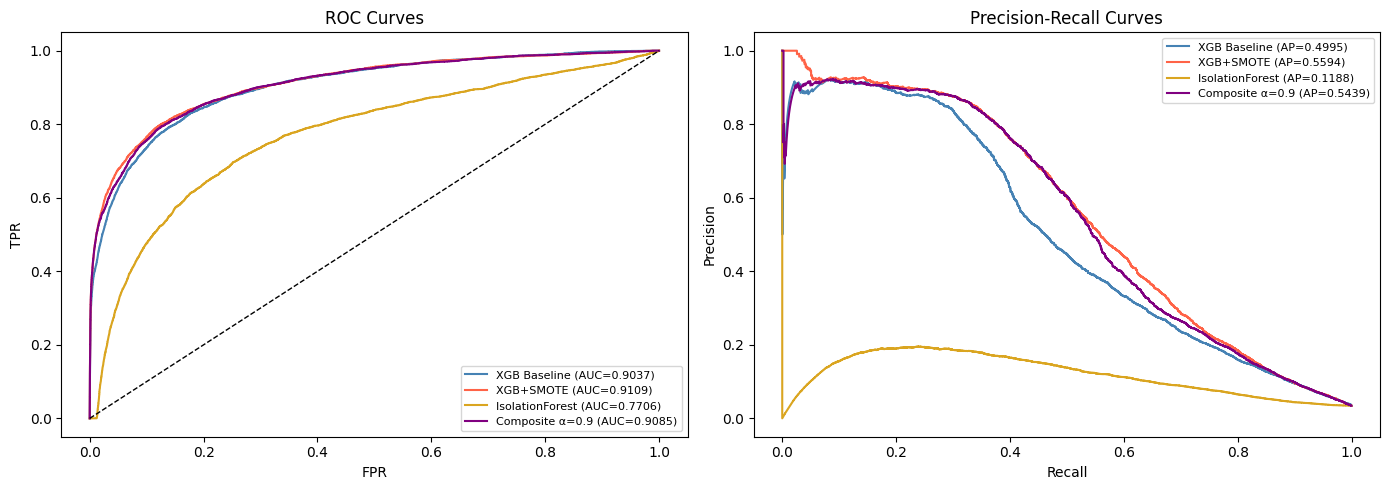

In [10]:
# Best alpha by AUC-PR (fraud detection cares more about precision-recall)
best_alpha = sens_df['auc_pr'].idxmax()
print(f'Best alpha: {best_alpha}')

comp_best = np.array([
    composite_score(float(xp), float(ip), alpha=best_alpha)
    for xp, ip in zip(y_pred_smt, iforest_scores_val)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'XGB Baseline': 'steelblue', 'XGB+SMOTE': 'tomato',
          'IsolationForest': 'goldenrod', f'Composite α={best_alpha}': 'purple'}

for (label, scores, color) in [
    ('XGB Baseline',           y_pred_base,       'steelblue'),
    ('XGB+SMOTE',              y_pred_smt,        'tomato'),
    ('IsolationForest',        iforest_scores_val,'goldenrod'),
    (f'Composite α={best_alpha}', comp_best,      'purple'),
]:
    plot_curves(y_val, scores, label, axes[0], axes[1], color)

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/03_model_comparison_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Save Model Artifacts

In [11]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_base, '../models/xgboost_baseline.pkl')
joblib.dump(xgb_smt,  '../models/xgboost_smt.pkl')
joblib.dump(iforest,  '../models/iforest_model.pkl')
joblib.dump({'best_alpha': best_alpha,
             'amount_mean': joblib.load('../models/amount_stats.pkl')['mean'],
             'amount_std':  joblib.load('../models/amount_stats.pkl')['std']},
            '../models/scoring_config.pkl')

print('Models saved:')
for p in ['xgboost_baseline.pkl','xgboost_smt.pkl','iforest_model.pkl','scoring_config.pkl']:
    size = os.path.getsize(f'../models/{p}') / 1e6
    print(f'  models/{p}  ({size:.1f} MB)')

Models saved:
  models/xgboost_baseline.pkl  (3.0 MB)
  models/xgboost_smt.pkl  (5.7 MB)
  models/iforest_model.pkl  (1.9 MB)
  models/scoring_config.pkl  (0.0 MB)


## Summary

All runs tracked in `mlruns/` under experiment `fraud_detection_phase1`.

| Run | Description |
|-----|-------------|
| xgb_baseline | XGBoost with scale_pos_weight, raw features |
| xgb_smotetomek | XGBoost on SMOTE-resampled training set |
| isolation_forest | IsolationForest fit on legitimate transactions only |
| composite_alpha_* | 5 sensitivity runs over composite weight α |

Best model selected by **AUC-PR** — appropriate for imbalanced fraud detection.